# 智能体
以 大语言模型为推理与决策核心 ，结合 `记忆` 、 `工具调用` 与 `环境交互能力`，能够进行 `规划决策` 并执行 `复杂任务` 以达成目标的软件系统。
- 理解用户问题
- 如何拆解任务
- 判断是否需要工具
- 需要调用那些工具
- 如何利用好工具结果生成回答&推进任务

## Agent核心组件
![Agent组成](../assets/agent.png)
- Action(行动)
- Tool(工具)
- Planning(规划决策)
- Memory(记忆)

## Agent创建与调用
LangChain1.0版本后，将所有Agent的创建方式统一为一个入口：`create_agent()`
同时在底层通过`中间件机制（Middleware）`和`标准模型接口(invoke/stream)`实现全局统一。


## Agent基本用法：模型的传入方式
create_agent 完整参数：
```python
from langchain.agents import create_agent

agent = create_agent(
    model: str | BaseChatModel, # 必需：聊天模型
    tools: List[BaseTool], # 必需：工具列表
    *,
    system_prompt: str = "", # 系统提示词
    middleware: Seguence[AgentMiddleware[StateT_co, ContextT]] = () # 中间件
    interrupt_before: List[str] = None, # 在某些工具前暂停（人机协作）
    interrupt_after: List[str] = None, # 在某些工具后暂停
    debug: bool = False # 调试模式
    name: str 丨 None = None, # 设置模型名称
)
```

### 1. 传入模型字符串
Agent根据传入的模型字符串，自主创建模型对象

<class 'langgraph.graph.state.CompiledStateGraph'>


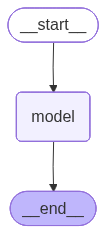

In [2]:
from langchain.agents import create_agent
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv(override=True)
agent = create_agent("deepseek-v4-flash")
print(type(agent))
display(Image(agent.get_graph().draw_mermaid_png()))

agent本质上是LangGraph的CompiledStateGraph实例，底层实现是一个图结构

### 2. 传入模型对象


<class 'langgraph.graph.state.CompiledStateGraph'>


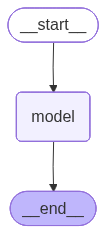

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
from langchain_qwq import ChatQwen

load_dotenv(override=True)
model = ChatQwen(
    model="deepseek-v4-flash",
    api_base=os.getenv("DASHSCOPE_API_BASE"),  # 国内 Key 必须用国内地址
)

agent = create_agent(model)
print(type(agent))
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 如何调用Agent

`agent.invoke()` 是Agent 最基本的同步调用方法，它会阻塞程序执行直到返回最终结果。具体的：
- 输入：传入的参数为字典类型，字典内通过 messages字段传递消息列表 。即：` {"messages":[{"role": "...", "content": "..."}]} `
- 输出：通过invoke调用Agent，底层可能会经历多轮交互，返回的是完整的 消息列表 ，被封装在
字典中，是 messages字段的值 。

In [4]:
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
from langchain_qwq import ChatQwen
from rich import print as rprint

load_dotenv(override=True)
model = ChatQwen(
    model="deepseek-v4-flash",
    api_base=os.getenv("DASHSCOPE_API_BASE"),  # 国内 Key 必须用国内地址
)

agent = create_agent(model)
# response = agent.invoke({"messages": ["你好"]}) # 默认是HumanMessage
response = agent.invoke({
"messages": [
    {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
    {"role": "user", "content": "100加上50等于多少？"}
]})
print(type(response))
rprint(response)

<class 'dict'>


{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='23703fe9-3f27-4270-8d57-e91197915be8'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='ffb49c95-3772-4077-843a-f3060347f4bc'
        ),
        AIMessage(
            content='哈哈，这个问题太简单啦！100加上50，就像你口袋里有100块零花钱，妈妈又给了你50块，那你总共有多少
呢？没错，就是150块！所以答案是150哦~ 😄',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': '我们被问到："100加上50等于多少？" 
这是一个简单的加法问题。作为小学数学老师，我应该耐心、幽默，讲解深入浅出。所以，回答应该直接给出答案，但也可以加上
一些幽默或解释。小学生可能知道，但也可以简单说明。'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 104,
                    'prompt_tokens': 23,
                    'total_tokens': 127,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 56,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-d129e842-8e27-9948-9a71-b30d5b5bf195',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f190c-9a50-77b2-9ef7-1d8997d4e6a8-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 23,
                'output_tokens': 104,
                'total_tokens': 127,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 56}
            }
        )
    ]
}